# **IDENTIFICACIÓN PARAMÉTRICA**

**INTEGRANTES:**
- Mariana Vásquez
- Estefanía Loaiza

In [ ]:
# Instalación de librerías necesarias para el proyecto
# pysid: librería de identificación de sistemas (ARX, ARMAX, OE, BJ)
# pandas: manejo de datos tabulares
# scikit-learn: métricas de evaluación (RMSE, MAE, R²)
# matplotlib: generación de gráficas
%pip install pysid
%pip install pandas 
%pip install scikit-learn
%pip install matplotlib


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### **IDENTIFICACIÓN DE SISTEMAS PARAMÉTRICOS**

**OBJETIVO:**
- Implementar técnicas de identificación paramétrica evaluando diferentes estructuras y órdenes de modelos para representar un sistema dinámico a partir de datos experimentales de entrada y salida.

**ESTRUCTURAS A EVALUAR:**
- 1. ARMAX
- 2. OE
- 3. BJ
- 4. ARX

In [ ]:
# LIBRERÍAS NECESARIAS

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import dlti, dlsim
from pysid import arx, armax, bj, oe
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score)



In [ ]:
def calcular_metricas(y_real, y_pred):
    """Función para calcular métricas de desempeño de los modelos
        Recibe la salida real y la salida predicha por el modelo
        Retorna tres métricas:
        - RMSE (Root Mean Squared Error): error cuadrático medio, penaliza errores grandes
        - MAE (Mean Absolute Error): error absoluto medio, mide la magnitud promedio del error
        - R² (Coeficiente de determinación): indica qué tan bien el modelo explica la varianza de los datos (1 = perfecto)"""

    rmse = np.sqrt(mean_squared_error(y_real, y_pred))

    mae = mean_absolute_error(y_real, y_pred)

    r2 = r2_score(y_real, y_pred)

    return rmse, mae, r2

In [4]:
# CARGA DE DATOS

# Se leen los datos experimentales almacenados en un CSV
data = pd.read_csv("D5.csv")
data.head() # Muestra las primeras filas del DataFrame para verificar la carga de datos


,t,u,y,uv,yv
0,0.00,1,0.000000,2.5,0.000000
1,0.01,1,0.214428,2.5,0.243912
2,0.02,1,0.885232,2.5,0.943198
3,0.03,1,0.072755,2.5,0.158252
4,0.04,1,0.672054,2.5,0.784173


In [5]:
# Vectores
t = np.array(data.t) # Tiempo
u = np.array(data.u) # Entrada
y = np.array(data.y) # Salida
uv = np.array(data.uv) # Entrada de validación
yv = np.array(data.yv) # Salida de validación


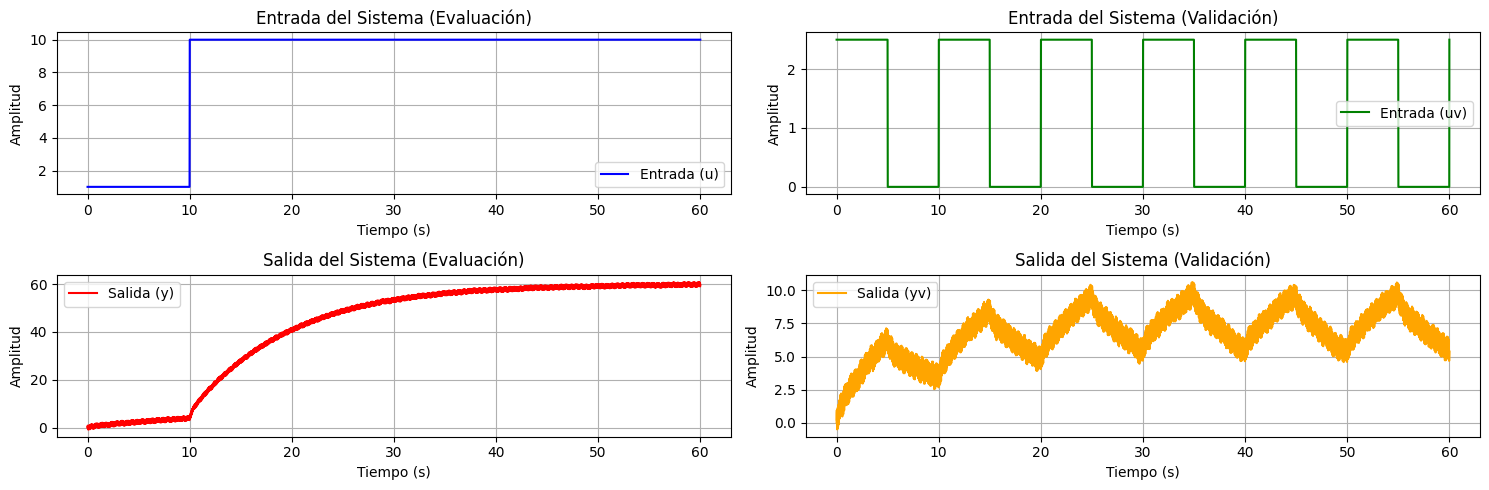

In [6]:
# Visualización de los datos

plt.figure(figsize=(15, 5))

# Entrada evalución
plt.subplot(2, 2, 1)
plt.plot(t, u, label='Entrada (u)', color='blue')
plt.title('Entrada del Sistema (Evaluación)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid()  
plt.legend()

# Entrada de validación
plt.subplot(2, 2, 2)
plt.plot(t, uv, label='Entrada (uv)', color='green')
plt.title('Entrada del Sistema (Validación)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid()
plt.legend()

# Salida evaluación
plt.subplot(2, 2, 3)
plt.plot(t, y, label='Salida (y)', color='red')
plt.title('Salida del Sistema (Evaluación)')
plt.xlabel('Tiempo (s)')        
plt.ylabel('Amplitud')
plt.grid()
plt.legend()

# Salida validación
plt.subplot(2, 2, 4)
plt.plot(t, yv, label='Salida (yv)', color='orange')
plt.title('Salida del Sistema (Validación)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Rizado es el ruido presente en la señal de salida, 
# que puede ser causado por perturbaciones externas, ruido de medición o variaciones inherentes al sistema. Es importante analizar el rizado para entender la calidad de los datos y su impacto en la identificación del modelo.
# Para modelarlo debemos caracterizarlo con la transformada rapida de fourier para ver el valor de la frecuencia del rizado y así poder modelarlo con un filtro de Butterworth o similar.

CARACTERIZACIÓN

In [ ]:
# Parámetros de muestreo
# N: cantidad total de muestras en la señal de salida
# Ts: periodo de muestreo promedio calculado a partir de las diferencias entre instantes de tiempo
# Fs = 1/Ts: frecuencia de muestreo en Hz
N = len(y)  # Número de muestras
Ts = np.mean(np.diff(t))  # Periodo de muestreo
print(f"Periodo de muestreo (Ts): {Ts:.4f} s, Frecuencia de muestreo (Fs): {1/Ts:.2f} Hz")

Periodo de muestreo (Ts): 0.0100 s, Frecuencia de muestreo (Fs): 100.00 Hz


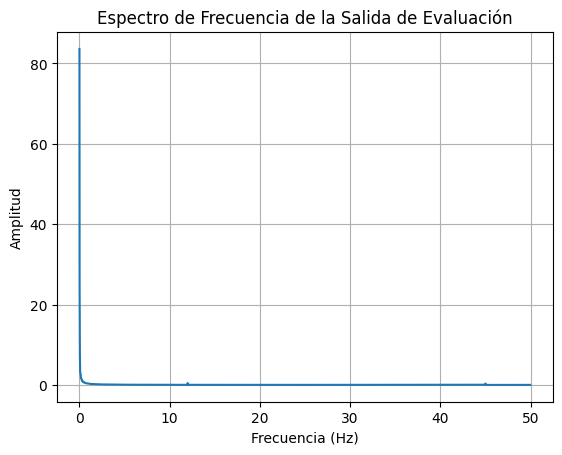

In [ ]:
# ANÁLISIS ESPECTRAL FFT

# El análisis espectral permite identificar:
# - ruido
# - rizado
# - frecuencias dominantes

yf = fft(y)  # Transformada rápida de Fourier  
xf = fftfreq(N, Ts)[:N//2] # Frecuencias correspondientes

plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
plt.title('Espectro de Frecuencia de la Salida de Evaluación')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.grid()

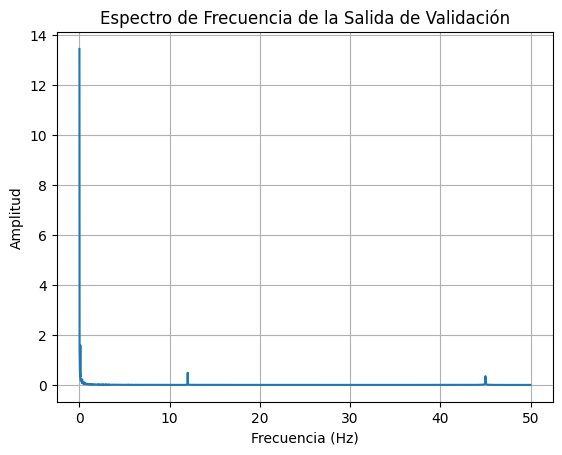

In [ ]:
# ANÁLISIS ESPECTRAL FFT - SEÑAL DE VALIDACIÓN
# Se aplica la Transformada Rápida de Fourier (FFT) a la señal de salida de validación (yv)
# para identificar las frecuencias dominantes y posible rizado o ruido
N = len(yv)  # Número de muestras de la señal de validación

yf = fft(yv)  # Transformada rápida de Fourier de la señal de validación
xf = fftfreq(N, Ts)[:N//2] # Frecuencias correspondientes (solo la mitad positiva del espectro)

# Gráfica del espectro de frecuencia
plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
plt.title('Espectro de Frecuencia de la Salida de Validación')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.grid()

# Muestra la distribución de frecuencias de la señal para identificar el rizado

In [10]:
# Sintaxis para utilizar las estructuras segun la librería

# AR : ar(na, y)
# ARX : arx(na, nb, nk, u, y)
# ARMA : arma(na, nc, y)
# ARMAX : armax(na, nb, nc, nk, u, y)
# OE : oe(nb, nc, nk, y, u)
# BJ : bj(nb, nc, nd, nf, nk, u, y)

In [ ]:
# TABLA DE RESULTADOS
# Lista vacía donde se almacenarán las métricas de cada modelo evaluado
# Cada entrada contendrá: nombre del modelo, orden, métricas de evaluación y métricas de validación
resultados = []

TEST CON ESTRUCTURA OE


Evaluando modelo OE orden [1, 1, 1]
  OE  orden nb=1  nf=1  nk=1


/Users/ssalgado/.pyenv/versions/3.10.14/lib/python3.10/site-packages/pysid/identification/solvers.py:42: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  phi = concatenate((toeplitz(-y[L-1:Ny-1], -y[L-na:L][::-1]), toeplitz(u[L-nk:Nu-nk], u[L-nk-nb:L-nk+1][::-1])), axis=1)



--- EVALUACIÓN ---


/Users/ssalgado/.pyenv/versions/3.10.14/lib/python3.10/site-packages/scipy/signal/_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


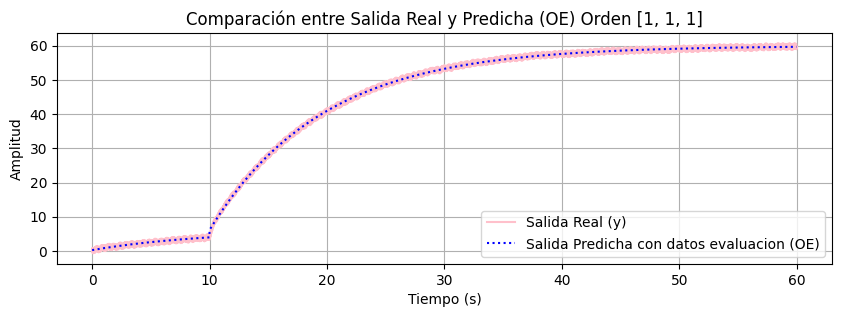

RMSE = 0.5172
MAE  = 0.4191
R²   = 0.9994

--- VALIDACIÓN ---


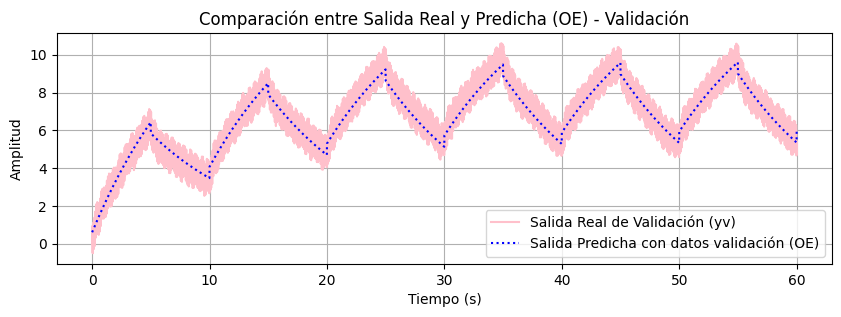

RMSE = 0.5322
MAE  = 0.4338
R²   = 0.9131

Evaluando modelo OE orden [2, 2, 1]
  OE  orden nb=2  nf=2  nk=1


/Users/ssalgado/.pyenv/versions/3.10.14/lib/python3.10/site-packages/pysid/identification/solvers.py:42: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  phi = concatenate((toeplitz(-y[L-1:Ny-1], -y[L-na:L][::-1]), toeplitz(u[L-nk:Nu-nk], u[L-nk-nb:L-nk+1][::-1])), axis=1)



--- EVALUACIÓN ---


/Users/ssalgado/.pyenv/versions/3.10.14/lib/python3.10/site-packages/scipy/signal/_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


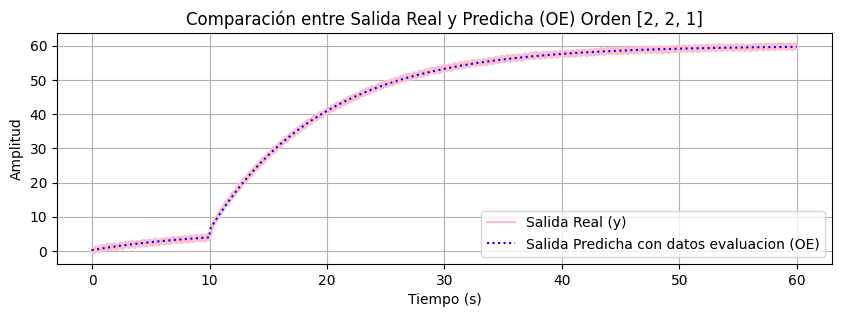

RMSE = 0.5161
MAE  = 0.4187
R²   = 0.9994

--- VALIDACIÓN ---


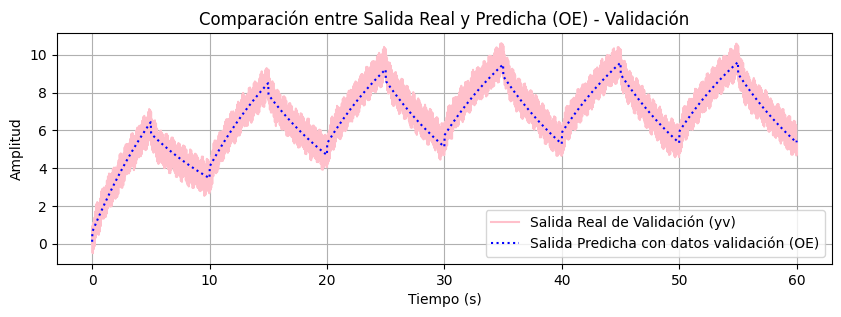

RMSE = 0.5311
MAE  = 0.4325
R²   = 0.9135

Evaluando modelo OE orden [3, 3, 1]
  OE  orden nb=3  nf=3  nk=1


/Users/ssalgado/.pyenv/versions/3.10.14/lib/python3.10/site-packages/pysid/identification/solvers.py:42: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  phi = concatenate((toeplitz(-y[L-1:Ny-1], -y[L-na:L][::-1]), toeplitz(u[L-nk:Nu-nk], u[L-nk-nb:L-nk+1][::-1])), axis=1)
/Users/ssalgado/.pyenv/versions/3.10.14/lib/python3.10/site-packages/scipy/signal/_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)



--- EVALUACIÓN ---


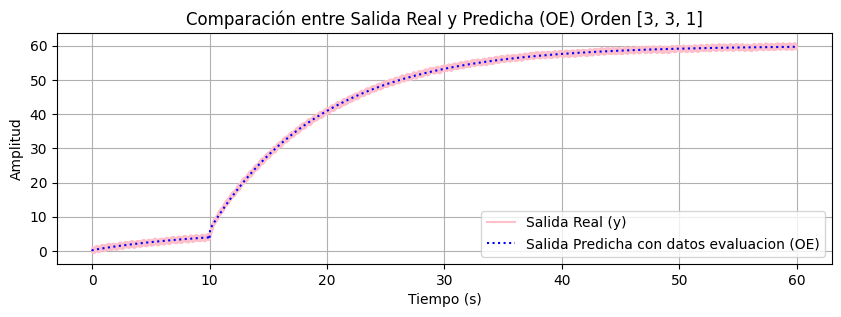

RMSE = 0.5148
MAE  = 0.4181
R²   = 0.9994

--- VALIDACIÓN ---


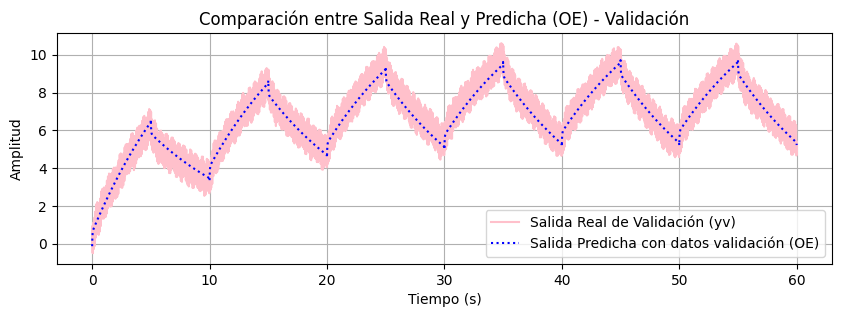

RMSE = 0.5297
MAE  = 0.4317
R²   = 0.9140


In [12]:

# ÓRDENES A EVALUAR

# [nb nf nk]

# nb -> orden numerador
# nf -> orden denominador
# nk -> retardo

# Se usan:
# Bajo  -> [1 1 1]
# Medio -> [2 2 1]
# Alto  -> [3 3 1]

ordenes_oe = [
    [1,1,1],
    [2,2,1],
    [3,3,1]
]

# CICLO DE EVALUACIÓN OE
for orden in ordenes_oe:

    print("\n================================================")
    print(f"Evaluando modelo OE orden {orden}")
    print("================================================")

    # Extraer órdenes
    nb, nf, nk = orden
    print(f"  OE  orden nb={nb}  nf={nf}  nk={nk}")

    # IDENTIFICACIÓN DEL MODELO
    model = oe(nb, nf, nk, u, y)

    # EXTRACCIÓN DE POLINOMIOS
    B = model.B[0,0]
    F = model.F[0,0]

    # CREACIÓN DEL SISTEMA DISCRETO
    system = dlti(B, F, dt=Ts)

    # EVALUACIÓN
    print("\n--- EVALUACIÓN ---")

    # SIMULACIÓN CON DATOS DE EVALUACIÓN
    # Crear señal predichaa usando el modelo
    t_out, y_sim_oe = dlsim(system, u) # y de la funcion de transferencia con la entrada u
    y_sim_oe = y_sim_oe.flatten()  # Aplanar el resultado para facilitar la comparación

    # comparacion real vs predicha
    plt.figure(figsize=(10, 3))
    plt.plot(t, y, label='Salida Real (y)', color='pink')
    plt.plot(t_out, y_sim_oe, label='Salida Predicha con datos evaluacion (OE)', color='blue', linestyle=':')
    plt.title(f'Comparación entre Salida Real y Predicha (OE) Orden {orden}')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.grid()
    plt.legend()
    plt.show()

    # CÁLCULO DE MÉTRICAS
    rmse_eval, mae_eval, r2_eval = calcular_metricas(y, y_sim_oe)

    # IMPRESIÓN DE MÉTRICAS
    print(f"RMSE = {rmse_eval:.4f}")

    print(f"MAE  = {mae_eval:.4f}")

    print(f"R²   = {r2_eval:.4f}")

    # VALIDACIÓN
    print("\n--- VALIDACIÓN ---")

    # Simulación usando datos nuevos
    t_out_val, y_sim_oe_val = dlsim(system, uv) # y de la funcion de transferencia con la entrada uv
    y_sim_oe_val = y_sim_oe_val.flatten()  # Aplanar el resultado para facilitar la comparación

    plt.figure(figsize=(10, 3))
    plt.plot(t, yv, label='Salida Real de Validación (yv)', color='pink')
    plt.plot(t_out_val, y_sim_oe_val, label='Salida Predicha con datos validación (OE)', color='blue', linestyle=':')
    plt.title('Comparación entre Salida Real y Predicha (OE) - Validación')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.grid()
    plt.legend()
    plt.show()


    # MÉTRICAS VALIDACIÓN
    rmse_val, mae_val, r2_val = calcular_metricas(yv, y_sim_oe_val)

    print(f"RMSE = {rmse_val:.4f}")
    print(f"MAE  = {mae_val:.4f}")
    print(f"R²   = {r2_val:.4f}")

    # GUARDAR RESULTADOS
    resultados.append([

        "OE",

        orden,

        rmse_eval,
        mae_eval,
        r2_eval,

        rmse_val,
        mae_val,
        r2_val
    ])

TEST CON ESTRUCTURA ARMAX


Evaluando modelo ARMAX orden [1, 1, 1, 1]


/Users/ssalgado/.pyenv/versions/3.10.14/lib/python3.10/site-packages/scipy/signal/_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)



--- EVALUACIÓN ---
RMSE = 0.4795
MAE  = 0.3911
R²   = 0.9995


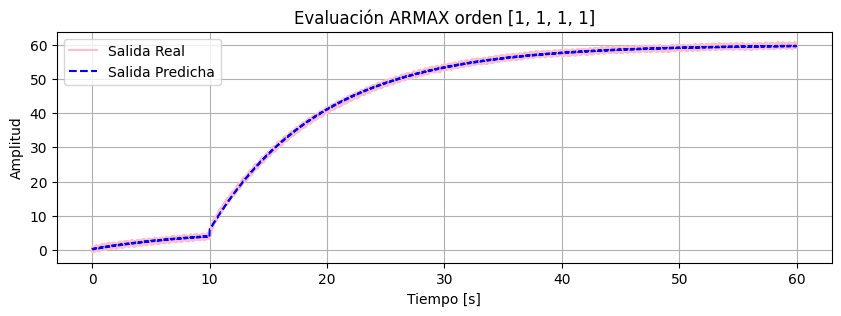


--- VALIDACIÓN ---
RMSE = 0.4905
MAE  = 0.4014
R²   = 0.9262


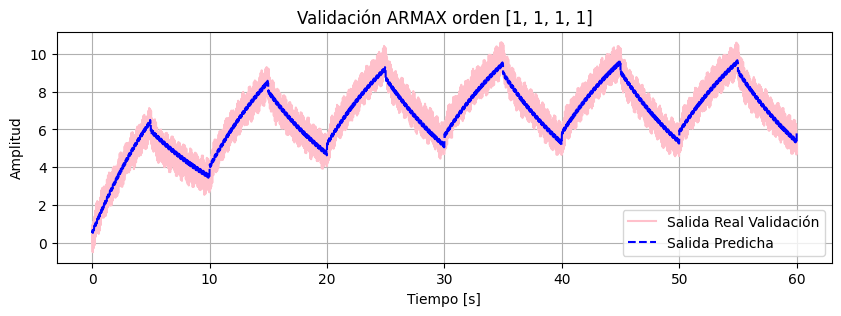


Evaluando modelo ARMAX orden [2, 2, 2, 1]


/Users/ssalgado/.pyenv/versions/3.10.14/lib/python3.10/site-packages/scipy/signal/_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)



--- EVALUACIÓN ---
RMSE = 3.1536
MAE  = 2.5664
R²   = 0.9782


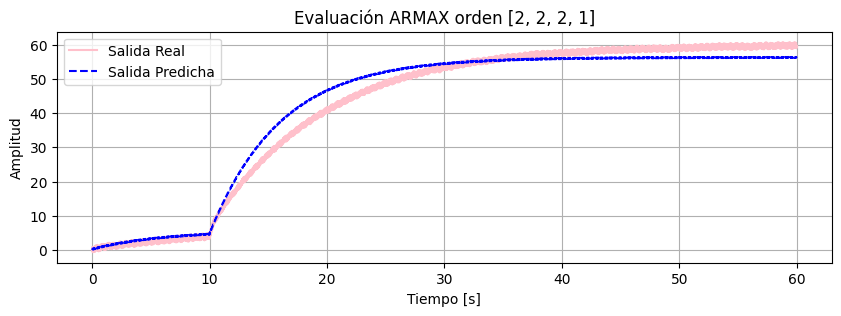


--- VALIDACIÓN ---
RMSE = 0.9361
MAE  = 0.7550
R²   = 0.7313


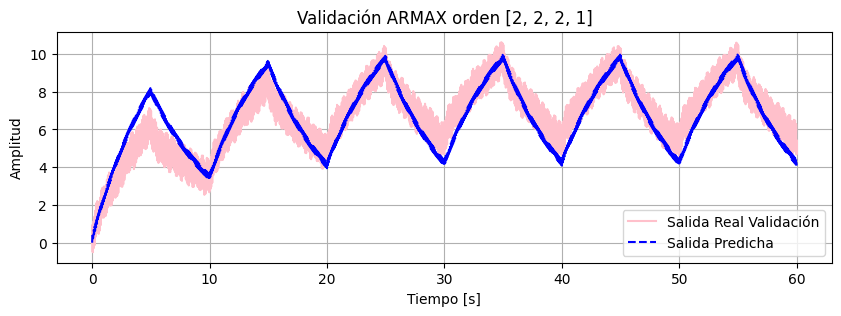


Evaluando modelo ARMAX orden [3, 3, 3, 1]


/Users/ssalgado/.pyenv/versions/3.10.14/lib/python3.10/site-packages/scipy/signal/_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)



--- EVALUACIÓN ---
RMSE = 0.4818
MAE  = 0.3920
R²   = 0.9995


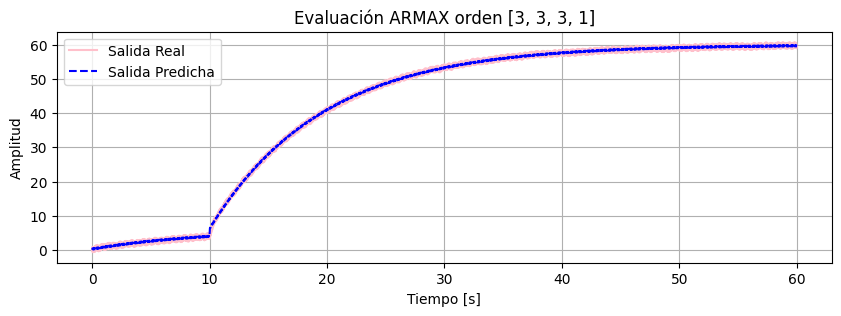


--- VALIDACIÓN ---
RMSE = 0.4968
MAE  = 0.4050
R²   = 0.9243


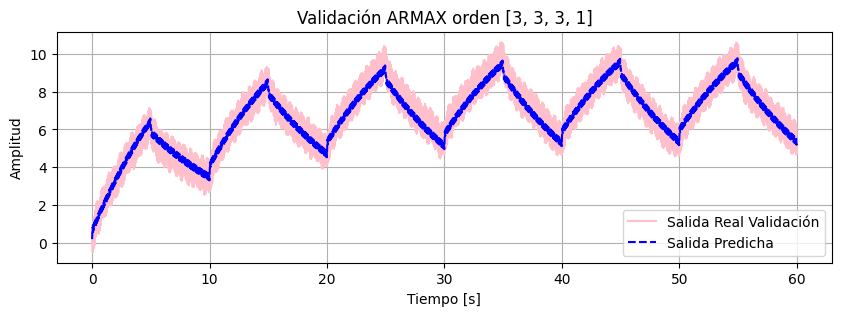

In [ ]:
# ORDENES A EVALUAR

# [na nb nc nk]
# na -> orden denominador
# nb -> orden numerador
# nc -> orden ruido
# nk -> retardo

ordenes_armax = [
    [1,1,1,1], # Orden bajo
    [2,2,2,1], # Orden medio
    [3,3,3,1]  # Orden alto
]

# CICLO DE EVALUACIÓN
for orden in ordenes_armax:

    print("\n================================================")
    print(f"Evaluando modelo ARMAX orden {orden}")
    print("================================================")

    # EXTRAER ÓRDENES
    na, nb, nc, nk = orden

    # IDENTIFICACIÓN DEL MODELO
    # El modelo se identifica usando:
    # u -> entrada entrenamiento
    # y -> salida entrenamiento

    model = armax(na, nb, nc, nk, u, y)

    # EXTRACCIÓN DE POLINOMIOS
    # Denominador
    A = model.A[0,0]
    # Numerador
    B = model.B[0,0]
    # Polinomio del ruido
    C = model.C[0,0]

    # SISTEMA DINÁMICO PRINCIPAL
    # H(z) = B(z)/A(z)

    system_signal = dlti(B, A, dt=Ts)

    # SISTEMA DEL RUIDO
    # Hn(z) = C(z)/A(z)
    system_noise = dlti(C, A, dt=Ts)

    # SEÑAL DE RUIDO
    # El ARMAX modela explícitamente la dinámica del ruido.
    # Aquí se usa una perturbación senoidal para evaluar el comportamiento del
    # modelo frente a perturbaciones.
    ruido_eval = 0.1 * np.sin(2 * np.pi * 12 * t)
    ruido_val = 0.1 * np.sin(2 * np.pi * 12 * t)

    # EVALUACIÓN
    print("\n--- EVALUACIÓN ---")
    
    # RESPUESTA DEL SISTEMA
    t_out, y_signal_eval = dlsim(system_signal, u)

    # RESPUESTA DEL RUIDO
    t_out, y_noise_eval = dlsim(system_noise, ruido_eval)

    # SALIDA TOTAL
    y_sim_armax_eval = (y_signal_eval.flatten() + y_noise_eval.flatten())

    # MÉTRICAS EVALUACIÓN
    rmse_eval, mae_eval, r2_eval = calcular_metricas(y, y_sim_armax_eval)

    print(f"RMSE = {rmse_eval:.4f}")
    print(f"MAE  = {mae_eval:.4f}")
    print(f"R²   = {r2_eval:.4f}")

    # GRÁFICA EVALUACIÓN
    plt.figure(figsize=(10,3))
    plt.plot(t, y, label='Salida Real', color='pink')
    plt.plot(t, y_sim_armax_eval, '--', label='Salida Predicha', color='blue')
    plt.title(f'Evaluación ARMAX orden {orden}')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud')
    plt.grid()
    plt.legend()
    plt.show()

    # VALIDACIÓN
    print("\n--- VALIDACIÓN ---")

    # RESPUESTA DEL SISTEMA
    t_out, y_signal_val = dlsim(system_signal, uv)
    
    # RESPUESTA DEL RUIDO
    t_out, y_noise_val = dlsim(system_noise, ruido_val)
    
    # SALIDA TOTAL
    y_sim_armax_val = (y_signal_val.flatten() + y_noise_val.flatten())

    # MÉTRICAS VALIDACIÓN
    rmse_val, mae_val, r2_val = calcular_metricas(yv, y_sim_armax_val)

    print(f"RMSE = {rmse_val:.4f}")
    print(f"MAE  = {mae_val:.4f}")
    print(f"R²   = {r2_val:.4f}")

    # GRÁFICA VALIDACIÓN
    plt.figure(figsize=(10,3))
    plt.plot(t, yv, label='Salida Real Validación', color='pink')
    plt.plot(t, y_sim_armax_val, '--', label='Salida Predicha', color='blue')
    plt.title(f'Validación ARMAX orden {orden}')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud')
    plt.grid()
    plt.legend()
    plt.show()

    # GUARDAR RESULTADOS
    resultados.append([

        "ARMAX",

        orden,

        rmse_eval,
        mae_eval,
        r2_eval,

        rmse_val,
        mae_val,
        r2_val
    ])


TEST CON ESTRUCTURA ARX


Evaluando modelo ARX orden [1, 1, 1]

--- EVALUACIÓN ---


/Users/ssalgado/.pyenv/versions/3.10.14/lib/python3.10/site-packages/scipy/signal/_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


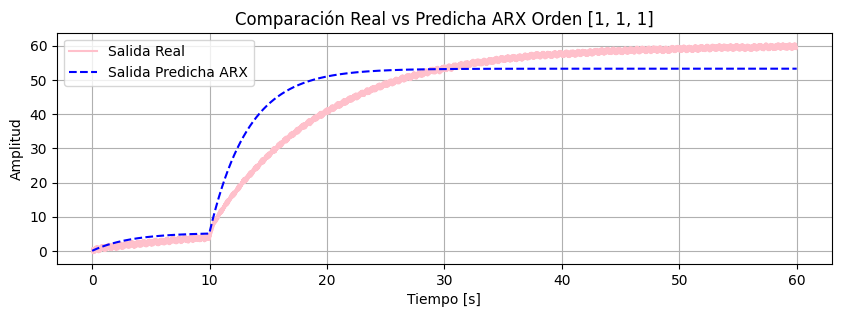

RMSE = 6.5554
MAE  = 5.2681
R²   = 0.9058

--- VALIDACIÓN ---


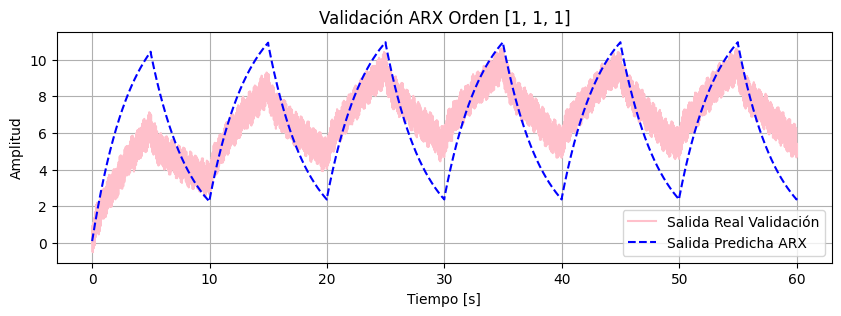

RMSE = 1.9169
MAE  = 1.5852
R²   = -0.1268

Evaluando modelo ARX orden [2, 2, 1]

--- EVALUACIÓN ---


/Users/ssalgado/.pyenv/versions/3.10.14/lib/python3.10/site-packages/scipy/signal/_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


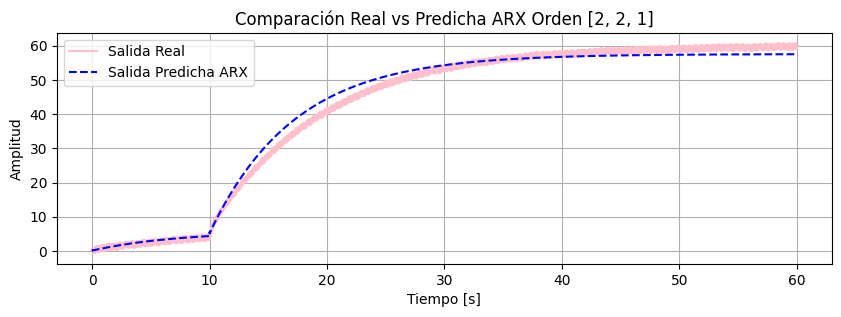

RMSE = 1.9834
MAE  = 1.6076
R²   = 0.9914

--- VALIDACIÓN ---


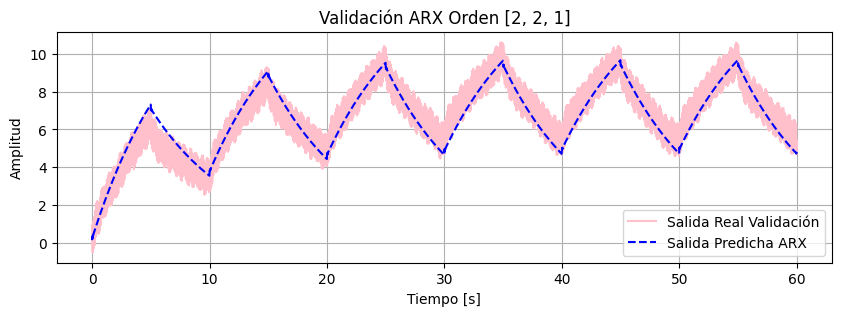

RMSE = 0.7005
MAE  = 0.5670
R²   = 0.8495

Evaluando modelo ARX orden [3, 3, 1]

--- EVALUACIÓN ---


/Users/ssalgado/.pyenv/versions/3.10.14/lib/python3.10/site-packages/scipy/signal/_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


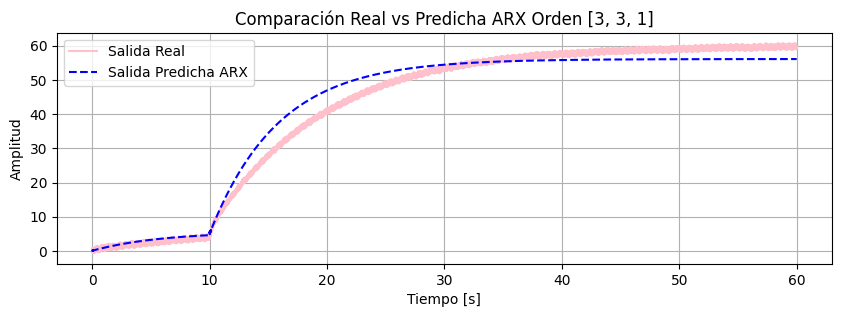

RMSE = 3.3458
MAE  = 2.7147
R²   = 0.9755

--- VALIDACIÓN ---


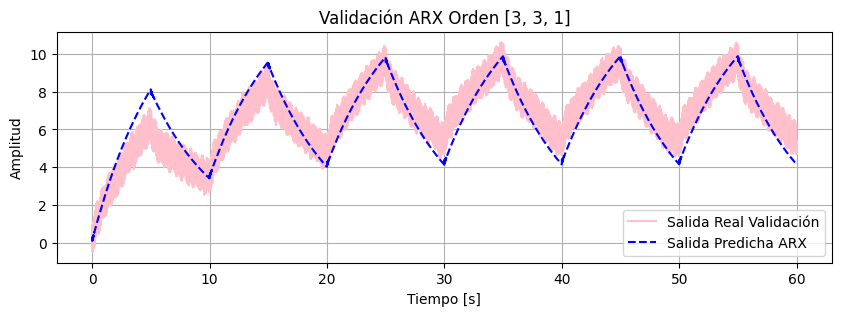

RMSE = 0.9468
MAE  = 0.7651
R²   = 0.7251


In [ ]:
# ORDENES A EVALUAR ARX
# Estructura ARX: y(t) = B(z)/A(z) * u(t) + 1/A(z) * e(t)
# El modelo ARX no tiene polinomio de ruido independiente; el ruido se filtra con el mismo denominador A(z)

# [na nb nk]
# na -> orden del polinomio A (denominador, parte autorregresiva)
# nb -> orden del polinomio B (numerador, parte exógena)
# nk -> retardo (delay) entre entrada y salida

ordenes_arx = [
    [1,1,1],   # Orden bajo
    [2,2,1],   # Orden medio
    [3,3,1]    # Orden alto
]

# CICLO DE EVALUACIÓN ARX
# Se itera sobre cada combinación de órdenes para comparar el desempeño
for orden in ordenes_arx:

    print("\n================================================")
    print(f"Evaluando modelo ARX orden {orden}")
    print("================================================")

    # Extraer los órdenes del modelo
    na, nb, nk = orden

    # IDENTIFICACIÓN DEL MODELO
    # Se estiman los coeficientes del modelo ARX usando los datos de entrenamiento (u, y)
    model = arx(na, nb, nk, u, y)

    # EXTRACCIÓN DE POLINOMIOS
    # A(z): polinomio del denominador (parte autorregresiva)
    # B(z): polinomio del numerador (parte exógena)
    A = model.A[0,0]
    B = model.B[0,0]

    # CREACIÓN DEL SISTEMA DISCRETO
    # Se construye la función de transferencia H(z) = B(z)/A(z)
    system = dlti(B, A, dt=Ts)

    # EVALUACIÓN
    # Se simula la respuesta del modelo con los datos de entrenamiento
    print("\n--- EVALUACIÓN ---")

    # Simulación del sistema con la entrada de evaluación
    t_out, y_sim_arx = dlsim(system, u)
    y_sim_arx = y_sim_arx.flatten()  # Aplanar para comparación

    # Gráfica comparativa: salida real vs salida predicha (evaluación)
    plt.figure(figsize=(10,3))
    plt.plot(t, y, label='Salida Real', color='pink')
    plt.plot(t_out, y_sim_arx, '--', label='Salida Predicha ARX', color='blue')
    plt.title(f'Comparación Real vs Predicha ARX Orden {orden}')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud')
    plt.grid()
    plt.legend()
    plt.show()

    # Cálculo e impresión de métricas de evaluación
    rmse_eval, mae_eval, r2_eval = calcular_metricas(y, y_sim_arx)

    print(f"RMSE = {rmse_eval:.4f}")
    print(f"MAE  = {mae_eval:.4f}")
    print(f"R²   = {r2_eval:.4f}")

    # VALIDACIÓN
    # Se simula con datos de validación (uv) para verificar la generalización del modelo
    print("\n--- VALIDACIÓN ---")

    # Simulación del sistema con la entrada de validación
    t_out_val, y_sim_arx_val = dlsim(system, uv)
    y_sim_arx_val = y_sim_arx_val.flatten()  # Aplanar para comparación

    # Gráfica comparativa: salida real vs salida predicha (validación)
    plt.figure(figsize=(10,3))
    plt.plot(t, yv, label='Salida Real Validación', color='pink')
    plt.plot(t_out_val, y_sim_arx_val, '--', label='Salida Predicha ARX', color='blue')
    plt.title(f'Validación ARX Orden {orden}')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud')
    plt.grid()
    plt.legend()
    plt.show()

    # Cálculo e impresión de métricas de validación
    rmse_val, mae_val, r2_val = calcular_metricas(yv, y_sim_arx_val)

    print(f"RMSE = {rmse_val:.4f}")
    print(f"MAE  = {mae_val:.4f}")
    print(f"R²   = {r2_val:.4f}")

    # Almacenar resultados para la tabla comparativa final
    resultados.append([
        "ARX",
        str(orden),
        rmse_eval,
        mae_eval,
        r2_eval,
        rmse_val,
        mae_val,
        r2_val
    ])

TEST CON ESTRUCTURA BJ


Evaluando modelo BJ orden [1, 1, 1, 1, 1]


/Users/ssalgado/.pyenv/versions/3.10.14/lib/python3.10/site-packages/pysid/identification/solvers.py:42: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  phi = concatenate((toeplitz(-y[L-1:Ny-1], -y[L-na:L][::-1]), toeplitz(u[L-nk:Nu-nk], u[L-nk-nb:L-nk+1][::-1])), axis=1)
/Users/ssalgado/.pyenv/versions/3.10.14/lib/python3.10/site-packages/scipy/signal/_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)



--- EVALUACIÓN ---


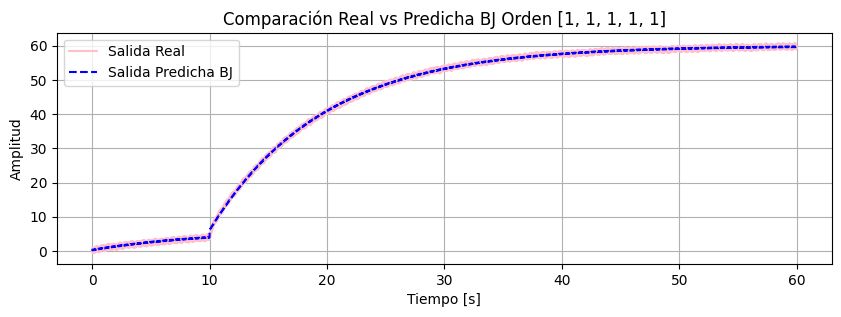

RMSE = 0.4707
MAE  = 0.3841
R²   = 0.9995

--- VALIDACIÓN ---


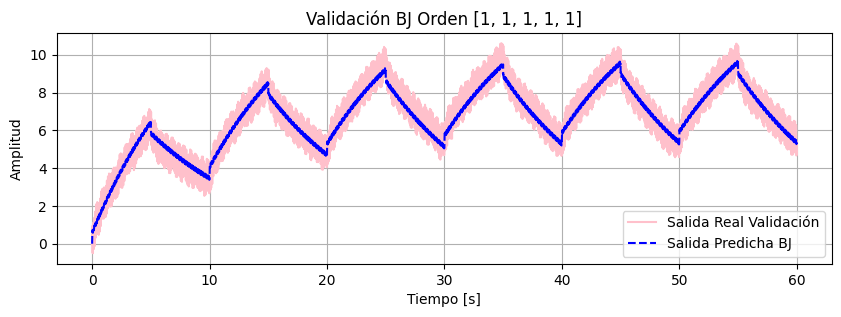

RMSE = 0.4876
MAE  = 0.3985
R²   = 0.9271

Evaluando modelo BJ orden [2, 1, 1, 1, 1]


/Users/ssalgado/.pyenv/versions/3.10.14/lib/python3.10/site-packages/pysid/identification/solvers.py:42: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  phi = concatenate((toeplitz(-y[L-1:Ny-1], -y[L-na:L][::-1]), toeplitz(u[L-nk:Nu-nk], u[L-nk-nb:L-nk+1][::-1])), axis=1)
/Users/ssalgado/.pyenv/versions/3.10.14/lib/python3.10/site-packages/scipy/signal/_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)



--- EVALUACIÓN ---


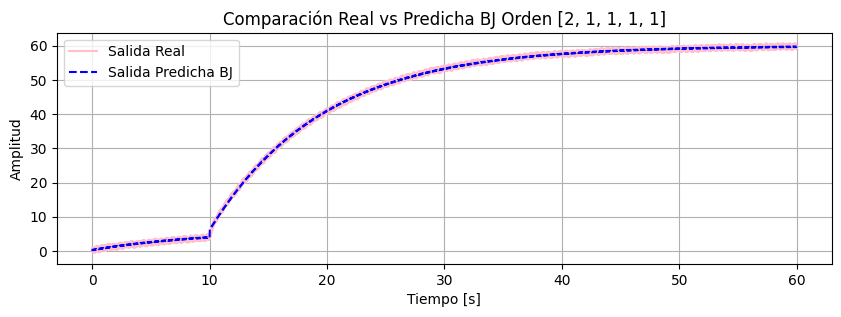

RMSE = 0.4746
MAE  = 0.3870
R²   = 0.9995

--- VALIDACIÓN ---


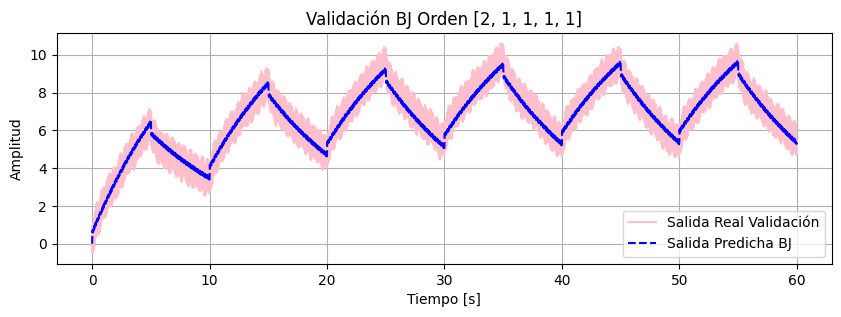

RMSE = 0.4913
MAE  = 0.4011
R²   = 0.9260

Evaluando modelo BJ orden [3, 1, 1, 1, 1]


/Users/ssalgado/.pyenv/versions/3.10.14/lib/python3.10/site-packages/pysid/identification/solvers.py:42: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  phi = concatenate((toeplitz(-y[L-1:Ny-1], -y[L-na:L][::-1]), toeplitz(u[L-nk:Nu-nk], u[L-nk-nb:L-nk+1][::-1])), axis=1)
/Users/ssalgado/.pyenv/versions/3.10.14/lib/python3.10/site-packages/scipy/signal/_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)



--- EVALUACIÓN ---


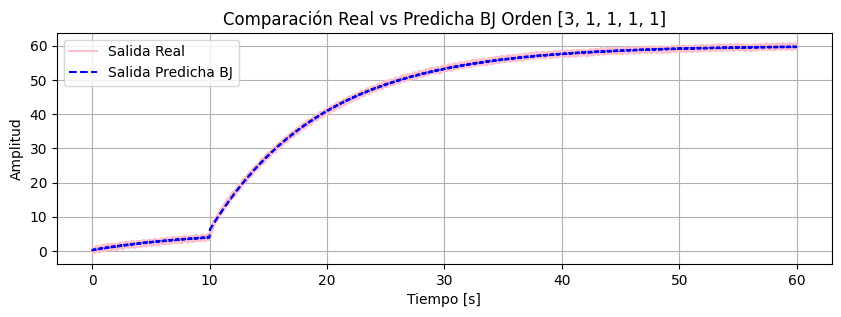

RMSE = 0.4689
MAE  = 0.3830
R²   = 0.9995

--- VALIDACIÓN ---


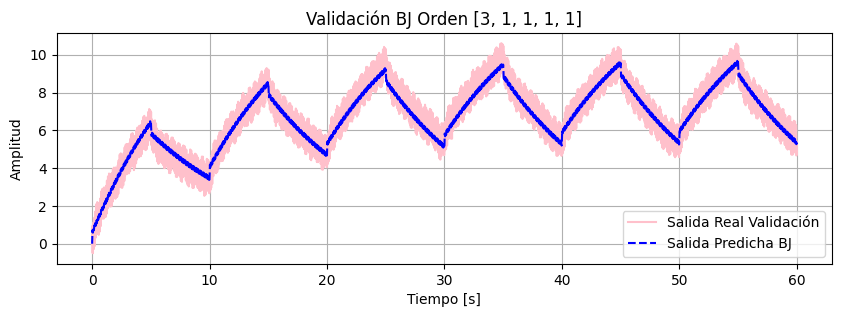

RMSE = 0.4856
MAE  = 0.3972
R²   = 0.9277


In [ ]:
# ORDENES A EVALUAR BJ
# Estructura Box-Jenkins: y(t) = B(z)/F(z) * u(t) + C(z)/D(z) * e(t)
# El modelo BJ separa completamente la dinámica del sistema y la del ruido
# Esto permite modelar independientemente la planta y las perturbaciones

# [nb nc nd nf nk]
# nb -> orden del numerador del sistema (B)
# nc -> orden del numerador del ruido (C)
# nd -> orden del denominador del ruido (D)
# nf -> orden del denominador del sistema (F)
# nk -> retardo (delay) entre entrada y salida

ordenes_bj = [
    [1,1,1,1,1],   # Orden bajo
    [2,1,1,1,1],   # Orden medio (se incrementa solo nb)
    [3,1,1,1,1]    # Orden alto (se incrementa solo nb)
]

# CICLO DE EVALUACIÓN BJ
# Se itera sobre cada combinación de órdenes para comparar el desempeño
for orden in ordenes_bj:

    print("\n================================================")
    print(f"Evaluando modelo BJ orden {orden}")
    print("================================================")

    # Extraer los órdenes del modelo
    nb, nc, nd, nf, nk = orden

    # Reshape de las señales a formato columna requerido por la librería pysid para BJ
    u = np.asarray(u).reshape(-1,1)
    y = np.asarray(y).reshape(-1,1)

    # IDENTIFICACIÓN DEL MODELO
    # Se estiman los coeficientes del modelo BJ usando los datos de entrenamiento (u, y)
    model = bj(nb, nc, nd, nf, nk, u, y)

    # EXTRACCIÓN DE POLINOMIOS
    # B(z): numerador del sistema
    # C(z): numerador del modelo de ruido
    # D(z): denominador del modelo de ruido
    # F(z): denominador del sistema
    B = model.B[0,0]
    C = model.C[0,0]
    D = model.D[0,0]
    F = model.F[0,0]

    # Asegurar dimensiones correctas para los polinomios
    B = np.squeeze(B)
    F = np.squeeze(F)

    # Ajuste de longitud: si F es más corto que B, se rellena con ceros
    if len(F) < len(B):
        F = np.pad(F, (0, len(B)-len(F)))
        
    # SISTEMA PRINCIPAL: H(z) = B(z)/F(z)
    # Representa la dinámica entrada-salida del sistema
    system_signal = dlti(B, F, dt=Ts)

    # SISTEMA DEL RUIDO: Hn(z) = C(z)/D(z)
    # Representa la dinámica de las perturbaciones
    system_noise = dlti(C, D, dt=Ts)

    # Señal de ruido sintética (senoidal a 12 Hz) para simular perturbaciones
    ruido_eval = 0.1 * np.sin(2 * np.pi * 12 * t)
    ruido_val = 0.1 * np.sin(2 * np.pi * 12 * t)

    # EVALUACIÓN
    # Se simula con los datos de entrenamiento para medir el ajuste del modelo
    print("\n--- EVALUACIÓN ---")

    # Respuesta del sistema principal ante la entrada de evaluación
    t_out, y_signal_eval = dlsim(system_signal, u)
    # Respuesta del filtro de ruido ante la perturbación simulada
    t_out, y_noise_eval = dlsim(system_noise, ruido_eval)

    # Salida total = respuesta del sistema + contribución del ruido filtrado
    y_sim_bj_eval = y_signal_eval.flatten() + y_noise_eval.flatten()

    # Gráfica comparativa: salida real vs salida predicha (evaluación)
    plt.figure(figsize=(10,3))
    plt.plot(t, y, label='Salida Real', color='pink')
    plt.plot(t, y_sim_bj_eval, '--', label='Salida Predicha BJ', color='blue')
    plt.title(f'Comparación Real vs Predicha BJ Orden {orden}')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud')
    plt.grid()
    plt.legend()
    plt.show()

    # Cálculo e impresión de métricas de evaluación
    rmse_eval, mae_eval, r2_eval = calcular_metricas(y, y_sim_bj_eval)

    print(f"RMSE = {rmse_eval:.4f}")
    print(f"MAE  = {mae_eval:.4f}")
    print(f"R²   = {r2_eval:.4f}")

    # VALIDACIÓN
    # Se simula con datos de validación (uv, yv) para medir la capacidad de generalización
    print("\n--- VALIDACIÓN ---")

    # Respuesta del sistema principal ante la entrada de validación
    t_out_val, y_signal_val = dlsim(system_signal, uv)
    # Respuesta del filtro de ruido ante la perturbación simulada
    t_out_val, y_noise_val = dlsim(system_noise, ruido_val)

    # Salida total de validación
    y_sim_bj_val = y_signal_val.flatten() + y_noise_val.flatten()

    # Gráfica comparativa: salida real vs salida predicha (validación)
    plt.figure(figsize=(10,3))
    plt.plot(t, yv, label='Salida Real Validación', color='pink')
    plt.plot(t, y_sim_bj_val, '--', label='Salida Predicha BJ', color='blue')
    plt.title(f'Validación BJ Orden {orden}')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud')
    plt.grid()
    plt.legend()
    plt.show()

    # Cálculo e impresión de métricas de validación
    rmse_val, mae_val, r2_val = calcular_metricas(yv, y_sim_bj_val)

    print(f"RMSE = {rmse_val:.4f}")
    print(f"MAE  = {mae_val:.4f}")
    print(f"R²   = {r2_val:.4f}")

    # Almacenar resultados para la tabla comparativa final
    resultados.append([
        "BJ",
        str(orden),
        rmse_eval,
        mae_eval,
        r2_eval,
        rmse_val,
        mae_val,
        r2_val
    ])

In [ ]:
# TABLA FINAL DE RESULTADOS
# Se construye un DataFrame con todos los resultados acumulados de los 4 modelos (OE, ARMAX, ARX, BJ)
# Cada fila contiene: modelo, orden, métricas de evaluación (RMSE, MAE, R²) y métricas de validación

tabla = pd.DataFrame(

    resultados,

    columns=[

        "Modelo",

        "Orden",

        "RMSE Eval",   # Error cuadrático medio - evaluación
        "MAE Eval",    # Error absoluto medio - evaluación
        "R2 Eval",     # Coeficiente de determinación - evaluación

        "RMSE Val",    # Error cuadrático medio - validación
        "MAE Val",     # Error absoluto medio - validación
        "R2 Val"       # Coeficiente de determinación - validación
    ]
)

# Imprimir la tabla comparativa completa
print("\n================================================")
print("TABLA FINAL DE RESULTADOS")
print("================================================")

print(tabla)


TABLA FINAL DE RESULTADOS
   Modelo            Orden  RMSE Eval  MAE Eval   R2 Eval  RMSE Val   MAE Val  \
0      OE        [1, 1, 1]   0.517182  0.419121  0.999414  0.532223  0.433800   
1      OE        [2, 2, 1]   0.516109  0.418673  0.999416  0.531111  0.432521   
2      OE        [3, 3, 1]   0.514832  0.418109  0.999419  0.529651  0.431740   
3   ARMAX     [1, 1, 1, 1]   0.479463  0.391129  0.999496  0.490509  0.401446   
4   ARMAX     [2, 2, 2, 1]   3.153612  2.566390  0.978197  0.936126  0.755005   
5   ARMAX     [3, 3, 3, 1]   0.481769  0.391955  0.999491  0.496752  0.405045   
6     ARX        [1, 1, 1]   6.555360  5.268100  0.905791  1.916886  1.585215   
7     ARX        [2, 2, 1]   1.983360  1.607622  0.991376  0.700455  0.566995   
8     ARX        [3, 3, 1]   3.345796  2.714700  0.975459  0.946766  0.765147   
9      BJ  [1, 1, 1, 1, 1]   0.470714  0.384113  0.999514  0.487555  0.398511   
10     BJ  [2, 1, 1, 1, 1]   0.474623  0.387046  0.999506  0.491299  0.401122   
1

In [ ]:
# SELECCIÓN DEL MEJOR MODELO
# Se selecciona el modelo con el mayor R² de validación (R2 Val)
# El R² de validación es el criterio más importante porque mide la capacidad
# de generalización del modelo con datos que no se usaron para entrenar
mejor_modelo = tabla.loc[tabla['R2 Val'].idxmax()]
print("\n================================================")
print("MEJOR MODELO SEGÚN R² DE VALIDACIÓN")
print("================================================")
print(mejor_modelo)


MEJOR MODELO SEGÚN R² DE VALIDACIÓN
Modelo                    BJ
Orden        [3, 1, 1, 1, 1]
RMSE Eval           0.468945
MAE Eval             0.38302
R2 Eval             0.999518
RMSE Val            0.485587
MAE Val             0.397151
R2 Val              0.927695
Name: 11, dtype: object
